
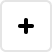
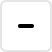
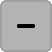
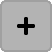
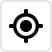
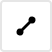
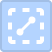
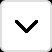
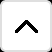
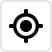
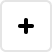
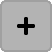
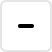
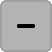
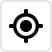
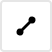
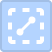
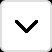
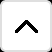
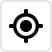

In [1]:
from lets_plot import *
import numpy as np
import pandas as pd

LetsPlot.setup_html()

# Test tag position and location

In [2]:
np.random.seed(1)

data = {'x': np.arange(10), 'y': np.random.normal(size=10)}

base = (
    ggplot(data, aes('x', 'y'))
    + geom_point(alpha=0.4)
    + ggsize(200, 144)
)

def with_tag(tag_text, pos):
    return (
        base
        + labs(tag=tag_text)
        + theme(plot_tag_position=pos)
    )

plots = [
    with_tag("0,1", [0.0, 1.0]),
    with_tag("½,1", [0.5, 1.0]),
    with_tag("1,1", [1.0, 1.0]),
    with_tag("0,½", [0.0, 0.5]),
    with_tag("½,½", [0.5, 0.5]),
    with_tag("1,½", [1.0, 0.5]),
    with_tag("0,0", [0.0, 0.0]),
    with_tag("½,0", [0.5, 0.0]),
    with_tag("1,0", [1.0, 0.0]),
]

nine_plots = (
    gggrid(
        plots,
        ncol=3,
        align=True,
        hspace=10,
        vspace=10
    ) 
+ ggsize(920, 800) 
+ theme(plot_tag=element_text(size=16, color="blue"))
)

### Tag location: plot

In [3]:
nine_plots + theme(plot_tag_location="plot")

### Tag location: panel

In [4]:
nine_plots + theme(plot_tag_location="panel")

### Tag location: margin

In [5]:
nine_plots + theme(plot_tag_location="margin")

# Variants of tag placement

In [6]:
np.random.seed(7)
n = 500
x = np.random.normal(0, 1.0, n)
y = 0.7 * x + np.random.normal(0, 0.8, n)
grp = np.where(x + y > 0, "G1", "G2")
r = np.sqrt(x*x + y*y)

df = pd.DataFrame({"x": x, "y": y, "grp": grp, "r": r})

base = (
    ggplot(df, aes("x", "y"))
    + ggsize(320, 240)
)

# A: correlation pattern (plain scatter + smooth)
pA = (
    base
    + geom_point(alpha=0.35)
    + geom_smooth(method="lm", se=True)
    + labs(title="Trend", subtitle="Linear relationship", tag="A")
)

# B: group separation (color by group)
pB = (
    base
    + geom_point(aes(color="grp"), alpha=0.5)
    + labs(title="Groups", subtitle="Two classes split by x+y", tag="B")
)

# C: density / magnitude feature (map r to size)
pC = (
    base
    + geom_point(aes(size="r"), alpha=0.35)
    + labs(title="Magnitude", subtitle="Point size ~ distance from origin", tag="C")
)

pABC = (gggrid([pA, pB, pC], ncol=3, align=True, hspace=10)
    + theme_minimal()
    + ggsize(1020, 320)
)

### Tag inside the panel

In [7]:
pABC + theme(
        plot_tag=element_text(size=48, color="rgba(64, 80, 255, 0.18)", face="bold"),
        plot_tag_location="panel",
        plot_tag_position=[0.15, 0.85]
    )

### Tag default placement

In [8]:
pABC + theme(
        plot_tag=element_text(size=20, color="gray70", face="bold"),
        plot_tag_prefix="(",
        plot_tag_suffix=")"
    )

### Tag on the top

In [9]:
pABC + theme(
        plot_tag=element_text(size=20, color="gray70", face="bold"),
        plot_tag_location="margin",
        plot_tag_position="top",
        plot_tag_prefix="-",
        plot_tag_suffix="-"
    )

In [10]:
df = pd.DataFrame({
    "label": ["A", "B", "C", "D"],
    "value": [45, 25, 20, 30]
})
df["ymax"] = df["value"].cumsum()
df["ymin"] = df["ymax"] - df["value"]

def pie_plot(tag_pos, title, subtitle, caption, tag_text = None):
    return (
        ggplot(df)
        + geom_pie(aes(fill="label", weight="value"))
        + labs(
            title=title,
            subtitle=subtitle,
            caption=caption,
            tag=tag_text
        )
        + theme_minimal()
        + theme(
            plot_tag=element_text(size=18),
            plot_tag_location="margin",
            plot_tag_position=tag_pos,
            plot_margin=[12, 12, 12, 12],
        )
        + ggsize(320, 280)
    )

### Interaction with the title and caption

In [11]:
p_no_tag = pie_plot(
    tag_pos=None,
    title="Title (no tag)",
    subtitle="Subtitle",
    caption="Caption",
)

p_top = pie_plot(
    tag_pos="top",
    title="Title should move DOWN",
    subtitle="Subtitle follows title",
    caption="Caption stays at bottom",
    tag_text="TOP TAG"
)

p_bottom = pie_plot(
    tag_pos="bottom",
    title="Title stays at top",
    subtitle="Subtitle stays under title",
    caption="Caption should move UP",
    tag_text="BOTTOM TAG"
)

gggrid([p_no_tag, p_top, p_bottom], ncol=3, hspace=10) + ggsize(900, 380)

In [12]:
grid = pd.DataFrame([(i, j) for i in range(10) for j in range(7)], columns=["x", "y"])
grid["v"] = np.sin(grid["x"] / 1.4) + np.cos(grid["y"] / 1.1)

base = (
    ggplot(grid, aes("x", "y"))
    + geom_tile(aes(fill="v"))
    + scale_fill_gradient(low="#4575b4", high="#d73027")
    + theme_minimal()
    + theme(plot_margin=[14, 14, 14, 14])
    + ggsize(360, 260)
)

def mk(title, subtitle, tag_location, tag_position, hjust=None, vjust=None):
    th = dict(
        plot_tag=element_text(size=18, hjust=hjust, vjust=vjust),
        plot_tag_location=tag_location,
        plot_tag_position=tag_position,
    )

    return (
        base
        + labs(title=title, subtitle=subtitle, tag="Tag")
        + theme(**th)
    )

### Controlling layout

In [13]:
plots = [
    mk("Default: plot + topleft", "No layout shift (tag over plot area).",
        tag_location="plot", tag_position="top-left"),
    
    mk("margin + topleft", "Shifts BOTH: top + left margins reserved.",
        tag_location="margin", tag_position="top-left"),
    
    mk("margin + top (hjust=0)", "Shifts VERTICAL only",
        tag_location="margin", tag_position="top", hjust=0.0),
    
    mk("margin + left (vjust=1)", "Shifts HORIZONTAL only",
        tag_location="margin", tag_position="left", vjust=1.0
    )
]

gggrid(plots, ncol=2, align=True, hspace=12, vspace=12) + ggsize(760, 560)